# Partial swap controls

*Written by Shoichi Yip (with Claude). Last updated: 30 September 2026.*

For partial red-sector swap experiments we want a set of **control residues**: positions that are *not* part of the red or green sector, but that resemble the red sector in two independent ways — how conserved they are, and how close they sit to it in 3D — so swapping them can be compared against swapping actual red-sector residues.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from natsort import natsorted
from Bio.PDB import PDBParser, NeighborSearch

from alntk.alignment import Alignment
from alntk.conservation import compute_aa_freqs, normalized_entropy

## Load sector data

In [2]:
num = np.loadtxt("../data/iter_aln_v2_numbering.txt", dtype=str)
red_sector = np.loadtxt("../data/iter_aln_v2_redsector.txt").astype(int)
red_sector_icweights = np.loadtxt("../data/iter_aln_v2_redsector_icweights.txt")
green_sector = np.loadtxt("../data/iter_aln_v2_greensector.txt").astype(int)

## Most important red-sector residues (excluding residue 18)

The red sector's 17 residues, ranked by ICA loading (descending). Residue `18` sits at alignment column 2, far from the rest of the sector (columns 165–243, i.e. chymotrypsin residues 160–228) — it's excluded here because we want the subset that's both important *and* part of that contiguous stretch.

In [3]:
order = np.argsort(-red_sector_icweights)
ranked_labels = num[red_sector[order]]

ranked_labels_no18 = ranked_labels[ranked_labels != "18"]
top_important = ranked_labels_no18[:11]

print("In order of importance:", "+".join(top_important))
print("Naturally sorted:      ", "+".join(natsorted(top_important)))

In order of importance: 228+189+226+215+216+192+183+180+184+160+227
Naturally sorted:       160+180+183+184+189+192+215+216+226+227+228


## The stretch containing the red sector (excluding residue 18)

The alignment-column range spanning all red-sector residues except 18, derived from the data rather than hardcoded. Candidates are the stretch positions that are in neither the red nor the green sector.

In [4]:
red_sector_sorted = np.sort(red_sector)
stretch_min, stretch_max = red_sector_sorted[1:].min(), red_sector_sorted[1:].max()
stretch_idxs = np.arange(stretch_min, stretch_max + 1)

print(f"Stretch: alignment columns {stretch_min}-{stretch_max} "
      f"({num[stretch_min]}-{num[stretch_max]})")

Stretch: alignment columns 165-243 (160-228)


In [5]:
candidate_idxs = np.array(sorted(
    set(stretch_idxs) - set(red_sector) - set(green_sector)
))
candidate_labels = num[candidate_idxs]

print(f"{len(candidate_labels)} candidate residues (in the stretch, not red, not green sector):")
print("+".join(natsorted(candidate_labels)))

51 candidate residues (in the stretch, not red, not green sector):
161+162+163+164+165+166+167+169+170+171+173+173a+173b+173c+173d+174+175+176+177+178+179+181+185+186+187+188A+188b+190+199+200+201+202+203+204+204a+205+206+207+208+209+210+212+213+217+218+218a+222+223+223a+224+225


## Conservation

Normalized Shannon entropy per alignment position, $H/\log(q)$ with $q=21$ (gap + 20 amino acids), computed over the full alignment using the existing per-sequence weights (`iter_aln_v2_weights.txt`) as row weights in the frequency calculation — the standard phylogenetic-redundancy correction, unrelated to the per-position ICA weights used elsewhere.

0 = fully conserved, 1 = uniform over all 21 symbols.

In [6]:
aln = Alignment()
aln.import_from_fasta("../data/iter_aln_v2.faa")
seqs = aln.get_seqs()

seq_weights = np.loadtxt("../data/iter_aln_v2_weights.txt")
assert seq_weights.shape[0] == seqs.shape[0]

In [7]:
cols_of_interest = np.concatenate([red_sector, candidate_idxs])
freqs = compute_aa_freqs(seqs[:, cols_of_interest], seq_weights=seq_weights)
entropy = normalized_entropy(freqs)

red_entropy = entropy[:len(red_sector)]
candidate_entropy = entropy[len(red_sector):]

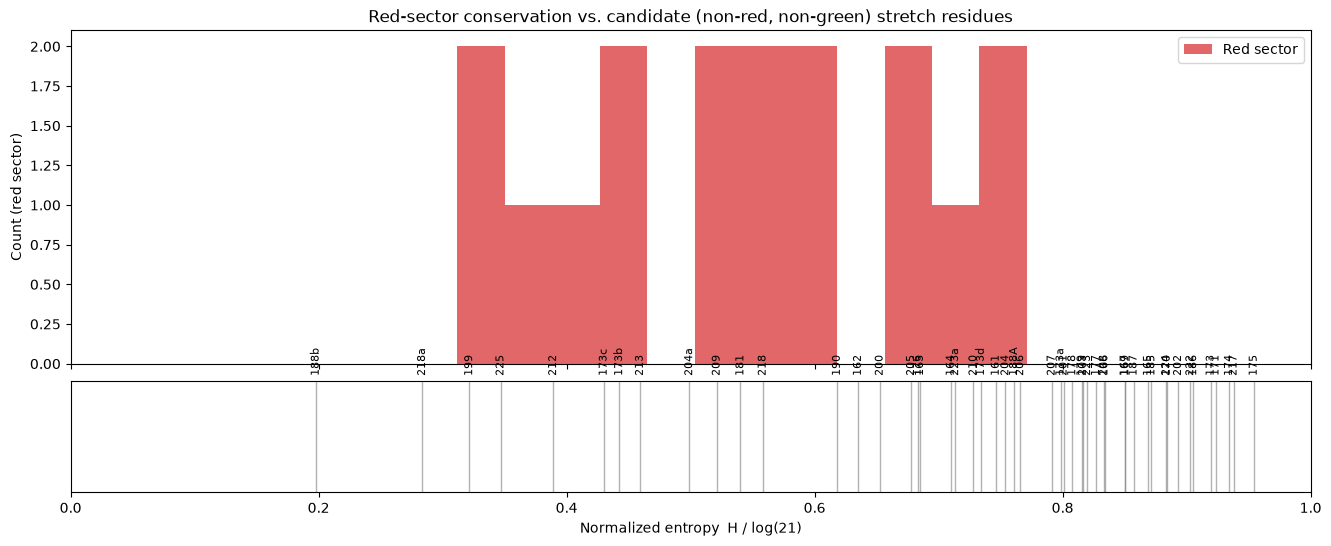

In [8]:
fig, (ax_hist, ax_candidates) = plt.subplots(
    2, 1, figsize=(16, 6), sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08},
)

ax_hist.hist(red_entropy, bins=12, color="tab:red", alpha=0.7, label="Red sector")
ax_hist.set_ylabel("Count (red sector)")
ax_hist.set_title("Red-sector conservation vs. candidate (non-red, non-green) stretch residues")
ax_hist.legend()

for lab, h in zip(candidate_labels, candidate_entropy):
    ax_candidates.axvline(h, color="tab:gray", alpha=0.6, linewidth=1)
    ax_candidates.text(h, 1.05, lab, rotation=90, ha="center", va="bottom", fontsize=8)

ax_candidates.set_ylim(0, 1)
ax_candidates.set_yticks([])
ax_candidates.set_xlabel("Normalized entropy  H / log(21)")
ax_candidates.set_xlim(0, 1)
plt.show()

In [9]:
import pandas as pd
import natsort

In [10]:
conservation_list = []
for l, e in zip(candidate_labels, candidate_entropy):
    if ((e>0.3) & (e<0.78)):
        conservation_list.append(str(l))

In [11]:
conservation_picks = natsort.natsorted(conservation_list)

### Pick the 17 closest by conservation

For each candidate, distance to conservation = how close its entropy is to the *nearest* red-sector entropy value. Rank ascending and take the 17 closest — independent of the entropy band above, this always returns exactly 17.

In [12]:
conservation_distance = np.min(
    np.abs(candidate_entropy[:, None] - red_entropy[None, :]), axis=1
)
conservation_order = np.argsort(conservation_distance)
conservation_top17 = candidate_labels[conservation_order[:17]]

print("Conservation-closest 17 residues:", "+".join(natsort.natsorted(conservation_top17)))

Conservation-closest 17 residues: 163+173b+173c+173d+176+181+188A+199+200+204+205+206+209+210+212+213+218


## Structural proximity

Which candidate residues fall within a given distance of the red sector (3TGI, chain E). Change `cutoff_angstrom` below and re-run the next cell to see how the candidate set changes.

In [13]:
def label_to_pdb_resid(label):
    """'188a' / '188A' -> (' ', 188, 'A'); '160' -> (' ', 160, ' ')"""
    label = label.strip()
    if label and label[-1].isalpha():
        return (" ", int(label[:-1]), label[-1].upper())
    return (" ", int(label), " ")


def normalize_label(label):
    return label.strip().upper()

In [14]:
pdb_file = "../data/3TGI.pdb"
chain_id = "E"

parser = PDBParser(QUIET=True)
structure = parser.get_structure("prot", pdb_file)
chain = structure[0][chain_id]
all_atoms = list(structure.get_atoms())
ns = NeighborSearch(all_atoms)

red_sector_resids = [label_to_pdb_resid(lab) for lab in num[red_sector]]
red_sector_residues = []
for resid, lab in zip(red_sector_resids, num[red_sector]):
    if resid in chain:
        red_sector_residues.append(chain[resid])
    else:
        print(f"Warning: red-sector residue {lab} not found in chain {chain_id}")

red_atoms = [atom for res in red_sector_residues for atom in res.get_atoms()]

In [15]:
cutoff_angstrom = 13.0  # <- change this and re-run the cell below

In [16]:
close_labels = set()
for atom in red_atoms:
    for neighbor in ns.search(atom.coord, cutoff_angstrom, level="R"):
        resnum, icode = neighbor.get_id()[1], neighbor.get_id()[2]
        close_labels.add(normalize_label(f"{resnum}{icode.strip()}"))

structural_candidates = [
    lab for lab in candidate_labels if normalize_label(lab) in close_labels
]

print(f"{len(structural_candidates)} / {len(candidate_labels)} candidates "
      f"within {cutoff_angstrom} \u00c5 of the red sector:")
print("+".join(natsorted(structural_candidates)))

38 / 51 candidates within 13.0 Å of the red sector:
161+162+163+164+165+166+167+169+170+171+173+174+175+176+177+178+179+181+185+186+187+188A+190+199+200+201+202+203+204+209+210+212+213+217+222+223+224+225


### Pick the 17 closest by structural distance

For each candidate, compute the minimum atom-atom distance to any red-sector atom (continuous, not a cutoff pass/fail). Rank ascending and take the 17 closest — independent of `cutoff_angstrom` above, this always returns exactly 17.

In [17]:
candidate_min_dist = []
for lab in candidate_labels:
    resid = label_to_pdb_resid(lab)
    if resid not in chain:
        candidate_min_dist.append(np.inf)
        continue
    res = chain[resid]
    d = min(atom - red_atom for atom in res.get_atoms() for red_atom in red_atoms)
    candidate_min_dist.append(d)
candidate_min_dist = np.array(candidate_min_dist)

structural_order = np.argsort(candidate_min_dist)
structural_top17 = candidate_labels[structural_order[:17]]

print("Structurally closest 17 residues:", "+".join(natsort.natsorted(structural_top17)))

Structurally closest 17 residues: 161+165+169+171+173+174+175+177+178+179+181+187+188A+190+199+217+225


## Two independent 17-residue control sets

These are two separate analyses, not merged — each stands on its own as a 17-residue control set matched to the red sector by one criterion.

In [18]:
print("Conservation-based (17):", "+".join(natsort.natsorted(conservation_top17)))
print("Structural-based   (17):", "+".join(natsort.natsorted(structural_top17)))

shared = sorted(
    set(conservation_top17) & set(structural_top17),
    key=lambda lab: int("".join(c for c in lab if c.isdigit()))
)
print(f"\n(for reference only, not used to pick anything: {len(shared)} residues appear in both lists: {'+'.join(shared)})")

Conservation-based (17): 163+173b+173c+173d+176+181+188A+199+200+204+205+206+209+210+212+213+218
Structural-based   (17): 161+165+169+171+173+174+175+177+178+179+181+187+188A+190+199+217+225

(for reference only, not used to pick anything: 3 residues appear in both lists: 181+188A+199)


## Are the two criteria related?

Scatter of all 51 candidates: x = conservation distance (how far each candidate's entropy is from the nearest red-sector entropy value), y = structural distance to the red sector. If the two criteria picked out similar residues, points would cluster near the bottom-left; if they're unrelated, no such pattern should appear.

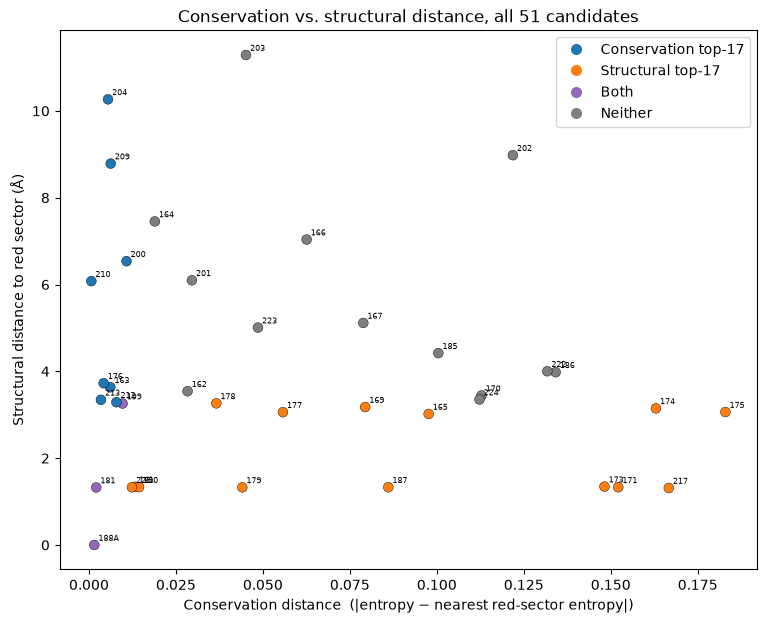

Spearman correlation (conservation distance vs. structural distance): rho=-0.261, p=0.065


In [19]:
from scipy.stats import spearmanr
from matplotlib.lines import Line2D

in_both = set(conservation_top17) & set(structural_top17)
colors = []
for lab in candidate_labels:
    if lab in in_both:
        colors.append("tab:purple")
    elif lab in conservation_top17:
        colors.append("tab:blue")
    elif lab in structural_top17:
        colors.append("tab:orange")
    else:
        colors.append("tab:gray")

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(conservation_distance, candidate_min_dist, c=colors, s=50, edgecolor="k", linewidth=0.3)
for lab, x, y in zip(candidate_labels, conservation_distance, candidate_min_dist):
    ax.annotate(lab, (x, y), fontsize=6, xytext=(3, 3), textcoords="offset points")

ax.set_xlabel("Conservation distance  (|entropy − nearest red-sector entropy|)")
ax.set_ylabel("Structural distance to red sector (\u00c5)")
ax.set_title("Conservation vs. structural distance, all 51 candidates")

legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="tab:blue", label="Conservation top-17", markersize=9),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="tab:orange", label="Structural top-17", markersize=9),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="tab:purple", label="Both", markersize=9),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="tab:gray", label="Neither", markersize=9),
]
ax.legend(handles=legend_elements)
plt.show()

rho, pval = spearmanr(conservation_distance, candidate_min_dist)
print(f"Spearman correlation (conservation distance vs. structural distance): rho={rho:.3f}, p={pval:.3f}")